In [3]:
import numpy as np 
import pandas as pd 
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import random

In [4]:
dataset = load_digits()
X = dataset.data
y = dataset.target

X_train, X_test, y_train, y_test = train_test_split(X,y , test_size=0.2, random_state=69)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
class NeuralNetwork:

    def __init__(self, input_size, hidden_size, output_size):
        # layer1
        self.w1 = np.random.randn(input_size, hidden_size) * 0.01 #scaling factor (not mandatory)
        self.b1 = np.zeros((1,hidden_size))

        # layer2 
        self.w2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1,output_size))

    def ReLU(self, z1):
        return np.maximum(0,z1)


    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def compute_loss(self, y_true, output):
        m = y_true.shape[0]  # number of samples
        correct_probs = output[np.arange(m), y_true]
        loss = -np.log(correct_probs + 1e-9)
        
        return np.mean(loss)


    def forward(self, X):
        self.X = X

        # layer1
        self.z1 = X @ self.w1 + self.b1
        self.a1 = self.ReLU(self.z1)


        # layer 2 
        self.z2 = self.a1 @ self.w2 + self.b2
        self.output = self.softmax(self.z2)
        return self.output



    def backward(self, y_true, learning_rate = 0.01):
        m = y_true.shape[0] # batch size 
        # erro 
        y_onehot = np.zeros((m, self.b2.shape[1]))
        y_onehot[np.arange(m), y_true] = 1

        dz2 = self.output - y_onehot # gradient of loss wrt z2 

        # gradient wrt weight and bias 
        dw2 = (self.a1.T @ dz2) / m 
        db2 = np.sum(dz2, axis=0, keepdims=True) / m 

        # hidden layer 
        da1 = dz2 @ self.w2.T # gradient w.r.t hidden activations 

        # relu gradient 
        dz1 = da1 * (self.z1 > 0 ) #gradient wrt z1 


        # gradient wrt weights and bias 
        dw1 = (self.X.T @ dz1) / m #xbatchis input 
        db1 = np.sum(dz1, axis=0, keepdims=True) / m

        # update 
        self.w2 = self.w2 - learning_rate*dw2
        self.b2 = self.b2 - learning_rate*db2
        self.w1 = self.w1 - learning_rate*dw1
        self.b1 = self.b1 - learning_rate*db1

    def train(self, X_train, y_train,epochs = 50, batch_size = 32, learning_rate = 0.01):
        losses = []

        for epoch in range(epochs):
            epoch_loss = 0 
            num_batches =  0 

            # shuffle data 
            indices = np.random.permutation(len(X_train))
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]


            for i in range(0, len(X_train), batch_size):
                X_batch = X_shuffled[i:i+batch_size]
                y_batch = y_shuffled[i:i+batch_size]

                # forward  
                output = self.forward(X_batch)
                loss = self.compute_loss(y_batch, output)

                # backward 
                self.backward(y_batch,learning_rate)

                epoch_loss += loss
                num_batches += 1 
            
            avg_loss = epoch_loss / num_batches
            losses.append(avg_loss)

            if(epoch + 1 ) %  10 ==0 :
                print(f" Epoch { epoch + 1}/ {epoch}, loss: {avg_loss:.4f}")
        return losses

    def predict(self, X):
        output = self.forward(X)
        return np.argmax(output, axis=1)


    def evaluate(self, X, y):
        predictions = self.predict(X)
        accuracy = np.mean(predictions == y)
        return accuracy
    


    


In [18]:
net = NeuralNetwork(input_size=64, hidden_size=16, output_size=10)

losses = net.train(X_train, y_train, epochs=100, learning_rate=0.1)


 Epoch 10/ 9, loss: 0.1079
 Epoch 20/ 19, loss: 0.0453
 Epoch 30/ 29, loss: 0.0265
 Epoch 40/ 39, loss: 0.0178
 Epoch 50/ 49, loss: 0.0129
 Epoch 60/ 59, loss: 0.0100
 Epoch 70/ 69, loss: 0.0081
 Epoch 80/ 79, loss: 0.0067
 Epoch 90/ 89, loss: 0.0057
 Epoch 100/ 99, loss: 0.0048


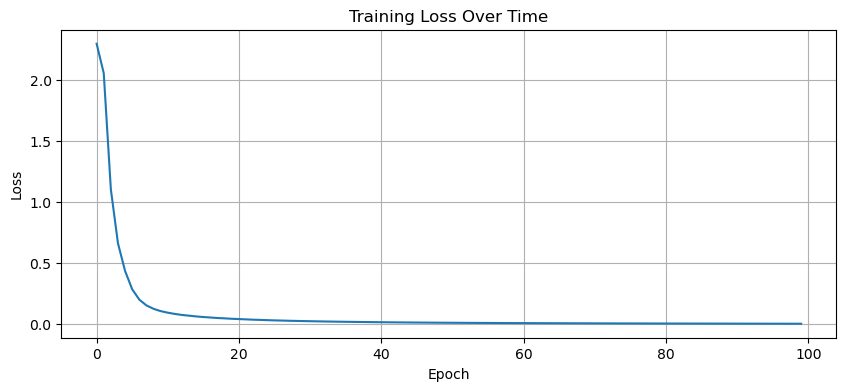

In [19]:
import  matplotlib.pyplot as plt 
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.grid()
plt.show()

In [20]:
def predict(self, X):
    """Make predictions on new data"""
    output = self.forward(X)
    return np.argmax(output, axis=1)  # Get class with highest probability

def evaluate(self, X, y):
    """Compute accuracy"""
    predictions = self.predict(X)
    accuracy = np.mean(predictions == y)
    return accuracy

# Test on training data
train_accuracy = net.evaluate(X_train, y_train)
print(f"Training accuracy: {train_accuracy:.2%}")

# Test on unseen test data (this is the real measure)
test_accuracy = net.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.2%}")

Training accuracy: 100.00%
Test accuracy: 97.50%
